# Spatial Analysis

- Reconstruct predictions into 2D images using lat and lon indices
- Assess the results from specific case studies
- Compare results against truth and GSO optical flow

In [1]:
import xgboost as xgb
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path
import numpy as np

import sys

sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import data_transform

In [2]:
model = xgb.XGBRegressor()

In [10]:
model.load_model("/scratch/er8/cd3022/xgb_models/alldata_model.json")

data_path = Path('/scratch/er8/cd3022/xgb_datasets/')

test_df  = pd.read_parquet(data_path / 'test.parquet')

X = test_df.drop(columns=['cloud_optical_depth'])
for n in range(1, 7):
    X = X.drop(columns=[f'cloud_optical_depth_t{n}'])
X = X.drop(columns=['month'])

y = test_df['cloud_optical_depth_t1']
y_log = data_transform.log_transform(y)

df = X.copy()
df['cloud_optical_depth_log'] = data_transform.log_transform(test_df['cloud_optical_depth'])
df['cloud_optical_depth_t1_log'] = y_log
df['forecast_log'] = model.predict(X)

ds_xgb = df.to_xarray()

In [4]:
def file_name_to_datetime64(file_path):
    '''
    Convert string from file name into np.datetime64 to be assigned as new coordinate to dataset.
    Assumes filename is in the format ".../YYYYmmddTHHMM..."
    
    INPUTS
    file_path (PosixPath): path to the file

    OUTPUTS
    np.datetime64 corresponding to the file name
    '''
    time_str = file_path.stem
    
    year = time_str[0:4]
    month = time_str[4:6]
    day = time_str[6:8]
    hour = time_str[9:11]
    minute = time_str[11:13]

    return np.datetime64(f'{year}-{month}-{day}T{hour}:{minute}')

def preprocess(ds):
    # Extract filename from encoding
    file_path = Path(ds.encoding["source"])
    
    # Add new "time" dimension
    t = file_name_to_datetime64(file_path)
    
    return (
        ds
        .rename({'time': 'forecast_time'})
        .expand_dims(time=[t])
        .sel(
            latitude=ds_xgb.latitude,
            longitude=ds_xgb.longitude
        )
    )

In [5]:
gso_files = []
for day in range(1,6):
    for month in ['02', '06', '10']:
        gso_path = Path(f'/scratch/er8/mm4602/gso/output/nwc_20240701_20251231/2025/{month}/0{day}')
        gso_files.extend([f for f in gso_path.glob('*.nc')])
    
ds_gso = xr.open_mfdataset(
    gso_files,
    preprocess=preprocess,
    combine='nested',
    concat_dim='time',
    parallel=True,
    chunks='auto'
)

/jobfs/167104080.gadi-pbs/ipykernel_1761591/923785019.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'forecast_time' ('forecast_time',) The recommendation is to set join explicitly for this case.
  ds_gso = xr.open_mfdataset(


In [6]:
ds_gso['cloud_optical_depth_log'] = data_transform.log_transform(ds_gso['cloud_optical_depth'])

In [7]:
# ds_gso['cloud_optical_depth'] = xr.where(ds_gso['cloud_optical_depth'] == 0, 0.1, ds_gso['cloud_optical_depth'])
# ds_gso['cloud_optical_depth'] = np.log(ds_gso.cloud_optical_depth)

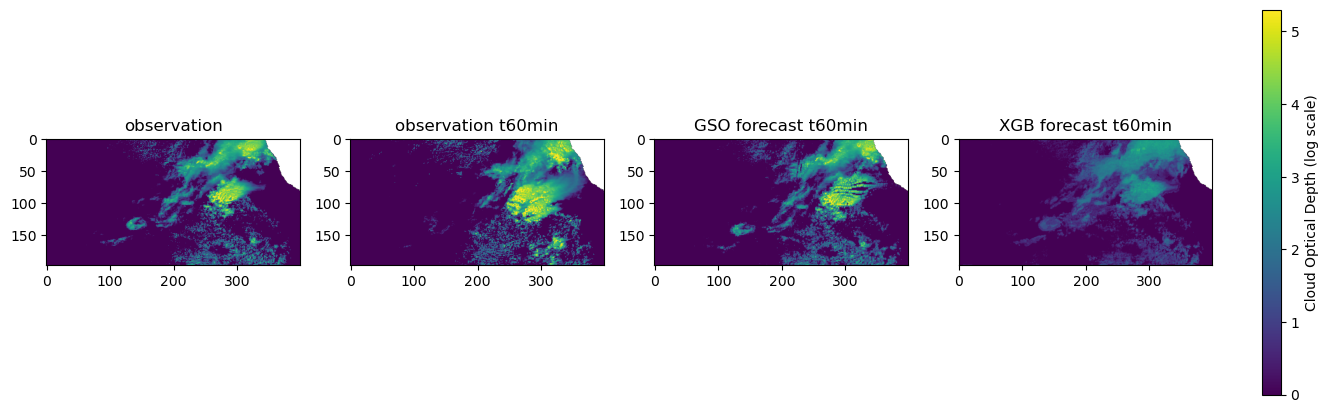

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16,5))
time= '2025-02-05T02:00'
f_time= '2025-02-05T03:00'

vmin=0
vmax=np.log(200)


im0 = ax[0].imshow(
    ds_xgb.cloud_optical_depth_log.sel(time=time),
    vmin=vmin, vmax=vmax
)
ax[1].imshow(
    ds_xgb.cloud_optical_depth_t1_log.sel(time=time),
    vmin=vmin, vmax=vmax
)

ax[2].imshow(
    ds_gso.cloud_optical_depth_log.sel(time=time, forecast_time=f_time),
    vmin=vmin, vmax=vmax
)

ax[3].imshow(
    ds_xgb.forecast_log.sel(time=time),
    vmin=vmin, vmax=vmax
)

ax[0].set_title('observation')
ax[1].set_title('observation t60min')
ax[2].set_title('GSO forecast t60min')
ax[3].set_title('XGB forecast t60min')

cbar = fig.colorbar(im0, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Cloud Optical Depth (log scale)')

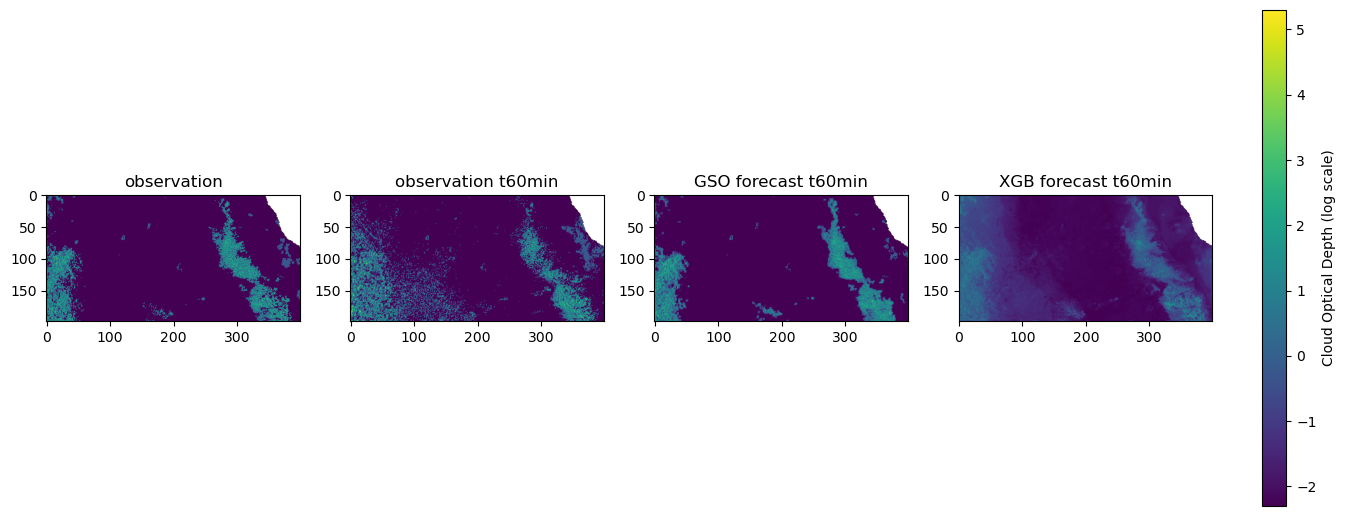

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
time= '2025-02-02T03:00'
f_time= '2025-02-02T04:00'

vmin=-2.3
vmax=np.log(200)


im0 = ax[0].imshow(
    ds_xgb.cloud_optical_depth_log.sel(time=time),
    vmin=vmin, vmax=vmax
)
ax[1].imshow(
    ds_xgb.cloud_optical_depth_t1_log.sel(time=time),
    vmin=vmin, vmax=vmax
)

im2 = ax[2].imshow(
    ds_gso.cloud_optical_depth_log.sel(time=time, forecast_time=f_time),
    vmin=vmin, vmax=vmax
)

ax[3].imshow(
    ds_xgb.forecast_log.sel(time=time),
    vmin=vmin, vmax=vmax
)

ax[0].set_title('observation')
ax[1].set_title('observation t60min')
ax[2].set_title('GSO forecast t60min')
ax[3].set_title('XGB forecast t60min')
cbar = fig.colorbar(im0, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Cloud Optical Depth (log scale)')

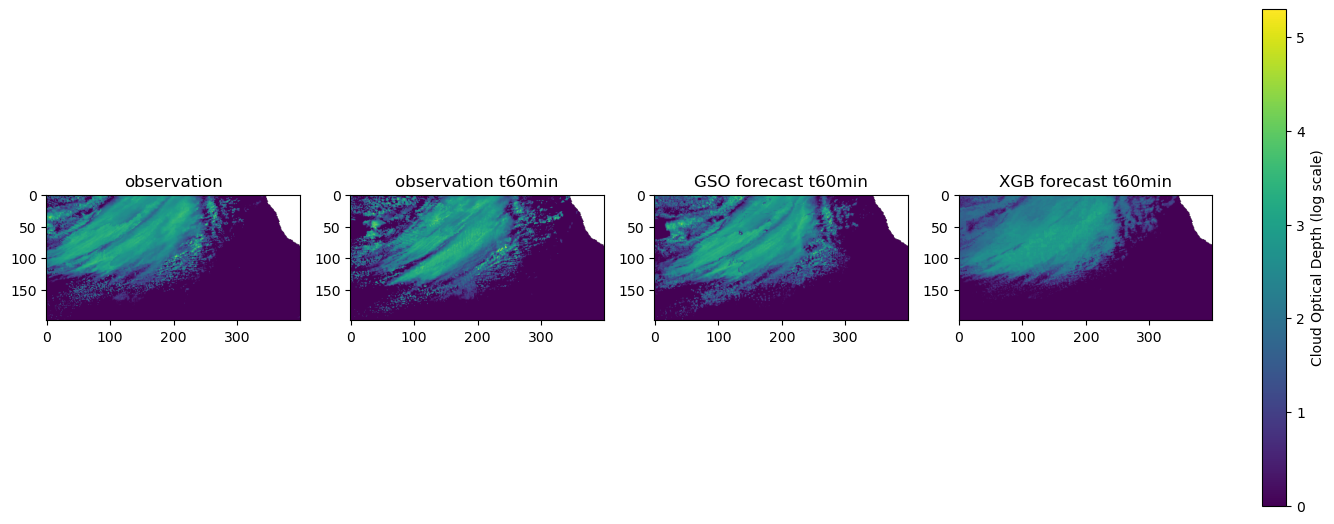

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
time= '2025-10-02T02:00'
f_time= '2025-10-02T03:00'

vmin=0
vmax=np.log(200)


im0 = ax[0].imshow(
    ds_xgb.cloud_optical_depth_log.sel(time=time),
    vmin=vmin, vmax=vmax
)
ax[1].imshow(
    ds_xgb.cloud_optical_depth_t1_log.sel(time=time),
    vmin=vmin, vmax=vmax
)

ax[2].imshow(
    ds_gso.cloud_optical_depth_log.sel(time=time, forecast_time=f_time),
    vmin=vmin, vmax=vmax
)

ax[3].imshow(
    ds_xgb.forecast_log.sel(time=time),
    vmin=vmin, vmax=vmax
)

ax[0].set_title('observation')
ax[1].set_title('observation t60min')
ax[2].set_title('GSO forecast t60min')
ax[3].set_title('XGB forecast t60min')

cbar = fig.colorbar(im0, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Cloud Optical Depth (log scale)')